# **Preliminary & Value Class**

In [ ]:
import math
from typing import Self


In [ ]:
class value:
  def __init__(self,x,pred=(), op='',label=''):
    self.data=x
    self.pred=set(pred) if pred else set()
    self.op=op
    self.grad=0;
    self.label=label
    self._backprop=lambda:None # if leaf no backprop.

  def __repr__(self):
    return f"value(data={self.data})"
  def __add__(self, other):
    other = other if isinstance(other, value) else value(other)
    out = value(self.data + other.data, (self, other), '+')
    def backprop():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backprop=backprop
    return out

  def __radd__(self, other):
    return self + other

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    other = other if isinstance(other, value) else value(other)
    return self + (-other)

  def __rsub__(self, other):
    other = other if isinstance(other, value) else value(other)
    return other + (-self)

  def __mul__(self, other):
    other = other if isinstance(other, value) else value(other)
    out = value(self.data * other.data, (self, other), '*')
    def backprop():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backprop=backprop
    return out

  def __rmul__(self, other):
    return self * other

  def __pow__(self, other):
    other = other if isinstance(other, value) else value(other)
    out = value(self.data ** other.data, (self, other), '**')
    def backprop():
      self.grad += (other.data*(self.data**(other.data-1))) * out.grad
      if isinstance(other, value):
         # Simplified for constant power, but adding logic for completeness
         pass
    out._backprop=backprop
    return out

  def tanh(self)->Self:
    x=self.data
    t_data=(math.exp(2*x)-1)/(math.exp(2*x)+1)
    out = value(t_data,(self,),'tanh')
    def backprop():
        self.grad += (1 - t_data**2) * out.grad
    out._backprop = backprop
    return out

  def backprop(self):
    topo = []
    visited = set ()
    def build_topo (v):
      if v not in visited:
        visited.add (v)
        for child in v.pred:
          build_topo(child)
        topo.append(v)
    build_topo (self)
    self.grad=1.0
    for node in reversed(topo):
      node._backprop()

In [ ]:
a = value (2.0, label='a')
b=value (-3.0,label='b')
c=value (10.0,label='c')
e=a*b;e.label='e'
d=e+c;d.label='d'
d


value(data=4.0)

In [ ]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.pred:      # ← your name
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # rectangular value node
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (
                getattr(n, "label", ""),
                n.data,
                n.grad
            ),
            shape='record'
        )

        # operation node
        if n.op:
            dot.node(name=uid + n.op, label=n.op)
            dot.edge(uid + n.op, uid)

    for n1, n2 in edges:
        if n2.op:
            dot.edge(str(id(n1)), str(id(n2)) + n2.op)

    return dot

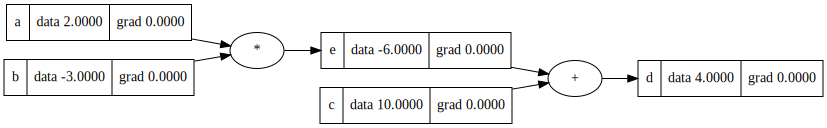

In [ ]:
draw_dot(d)

In [ ]:
# try to back propagate
d.grad=1.0

In [ ]:
# This function was removed as it was incorrectly implementing backpropagation and conflicting with the value class's internal backprop method.

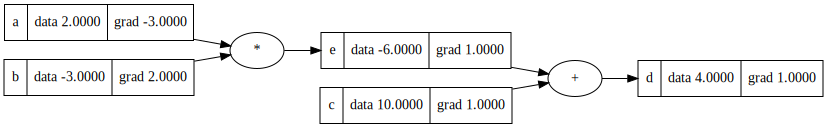

In [ ]:
d.backprop()
draw_dot(d)

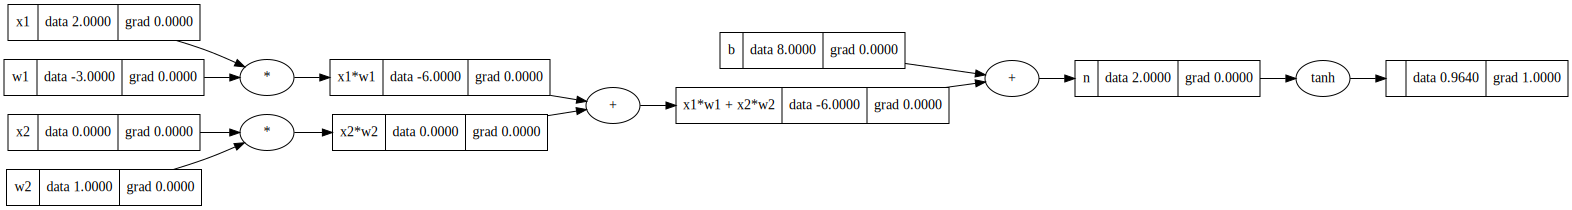

In [ ]:
# inputs x1,x2
x1 = value(2.0, label='x1')
x2 = value (0.0,label='x2')
# weights wl,w2
w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')
# bias of the neuron
b = value(8, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh();
o.grad=1
draw_dot(o)

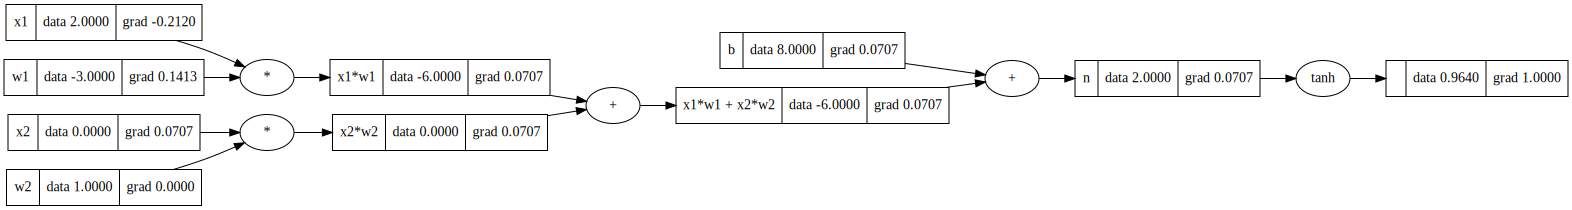

In [ ]:
o.backprop()
draw_dot(o)

# **PyTorch Edition**

In [ ]:
import torch

x1 = torch.Tensor([2.0]).double()
x2 = torch.Tensor([0.1]).double()
w1 = torch.Tensor([-3.0]).double()
w2 = torch.Tensor([1.0]).double()
b  = torch.Tensor([8]).double()

x1.requires_grad = True
x2.requires_grad = True
w1.requires_grad = True
w2.requires_grad = True
b.requires_grad  = True

y = x1 * w1 + x2 * w2 + b
o = torch.tanh(y)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.970451936700213
---
x2 0.058223038554805755
w2 0.005822303942239664
x1 -0.17466911566441726
w1 0.11644607710961151


In [ ]:
import torch


In [ ]:
import torch

# inputs x1, x2
x1 = torch.tensor(2.0, dtype=torch.double, requires_grad=True)
x2 = torch.tensor(0.0, dtype=torch.double, requires_grad=True)

# weights w1, w2
w1 = torch.tensor(-3.0, dtype=torch.double, requires_grad=True)
w2 = torch.tensor(1.0, dtype=torch.double, requires_grad=True)

# bias of the neuron
b = torch.tensor(8.0, dtype=torch.double, requires_grad=True)

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x2w2 = x2 * w2
x1w1x2w2 = x1w1 + x2w2
n = x1w1x2w2 + b
o = torch.tanh(n)

# backward pass (equivalent to: o.grad = 1)
o.backward()

print("o:", o.item())
print("---")
print("x1.grad:", x1.grad.item())
print("x2.grad:", x2.grad.item())
print("w1.grad:", w1.grad.item())
print("w2.grad:", w2.grad.item())
print("b.grad:", b.grad.item())

o: 0.9640275800758169
---
x1.grad: -0.2119524745594933
x2.grad: 0.07065082485316443
w1.grad: 0.14130164970632886
w2.grad: 0.0
b.grad: 0.07065082485316443


In [ ]:
import random

In [ ]:
class Neuron:
    def __init__(self, nin):
        self.w = [value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    def parameters(self):
      return self.w + [self.b]



class Layer :
  def __init__(self,nin,nout):
     self.neurons=[Neuron(nin) for _ in range(nout)] # create exactly nout no of neurons in this layer, each with nin inputs
  def __call__(self,x):# passing the tensor/vector in it
    output=[neuro(x) for neuro in self.neurons]
    return output
  def parameters(self):
    """ returns all params of the layer"""
    return [p for neuron in self.neurons for p in neuron.parameters() ]


class MLP:
  def __init__(self, nin, nouts): #nin--> input dimn, nout:->list mentioning what is o/p dimn of each layer
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    # for 1st one, input is nin,op is nout1 __> for second one ip is nout1 op is nout2...so on
  def __call__(self,x):
    for layer in self.layers:
      x=layer(x) # so that it becomes ip for next layer
    return x
  def parameters(self):
    """ returns all params of the network, concat the params of each layer"""
    return [p for layer in self.layers for p in layer.parameters() ]



# ---- outside the class ----
# x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])



In [ ]:
xS = [

  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0]
  ]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets
yout=[n(x) for x in xS]
print(yout)

[[value(data=0.44726119406861836)], [value(data=-0.5783665008314851)], [value(data=-0.6659941166290975)], [value(data=0.20025290585596844)]]


actual training

In [ ]:
#loss calculation
yout=[n(x) for x in xS]
loss = (sum((y - ypred[0])**2 for y, ypred in zip(ys, yout)))

In [ ]:
loss

value(data=1.234450339921735)

In [ ]:
loss.backprop()
# Now back prop just find the values of grad but doesnot update them --> grab all params and update them as params -0.1*grad

In [ ]:
# draw_dot(loss)

In [ ]:
params=n.parameters()

In [ ]:
for p in params:
  p.data-=0.1*(p.grad)

In [ ]:
yout=[n(x) for x in xS]


In [ ]:
yout

[[value(data=0.9065104395642916)],
 [value(data=-0.5966693210807066)],
 [value(data=-0.5984995800465167)],
 [value(data=0.8909003600174004)]]

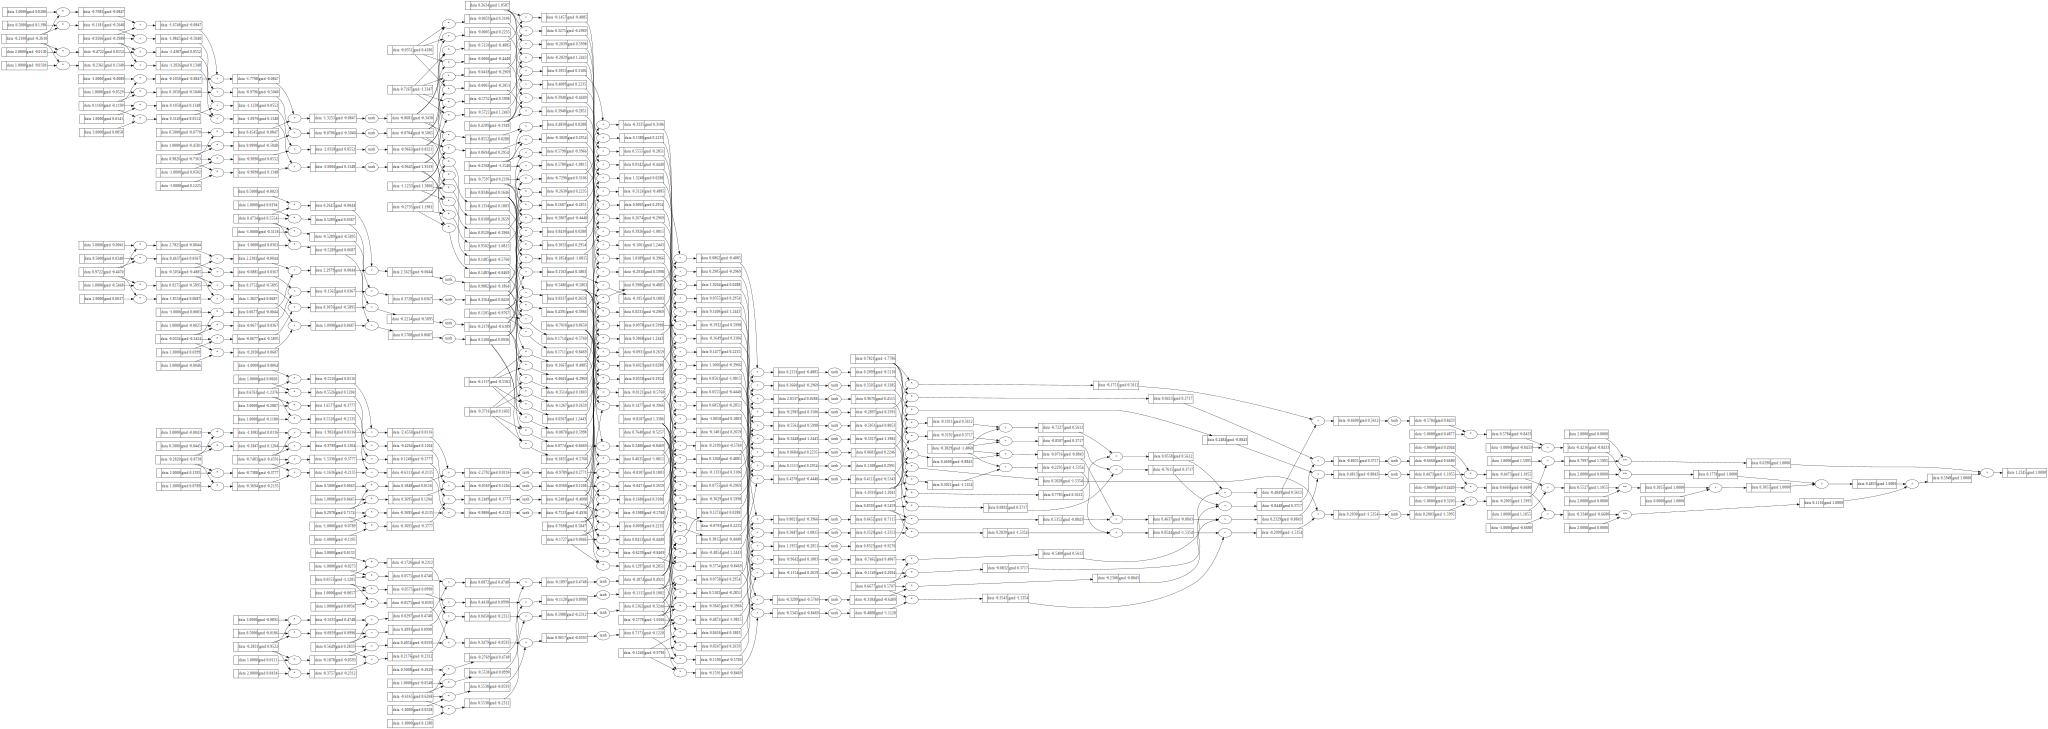

In [ ]:
draw_dot(loss)

looped training for pre-fixed epoch numbers


In [ ]:
# k being the epoch number
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xS]
    # Extract the first element from the list returned by n(x)
    loss = sum((y - yhat[0])**2 for y, yhat in zip(ys, ypred))

    # zero gradients first (important)
    for p in n.parameters():
        p.grad = 0.0

    # backward pass - use backprop() from your value class
    loss.backprop()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 0.34452125313511645
1 0.09508764133682313
2 0.08125823988999958
3 0.07153528012209348
4 0.06403027914599715
5 0.057970746561405384
6 0.052945364385906954
7 0.048699643560357726
8 0.0450616492084138
9 0.04190867115816759
10 0.03914982791320426
11 0.03671597226123262
12 0.03455338376880864
13 0.03261961380371971
14 0.03088063955374955
15 0.029308855208358547
16 0.02788161958533102
17 0.026580185027123716
18 0.025388894068553422
19 0.02429456807978557
